# 04 - VAR and VECM: Multivariate Macro-Financial System

This notebook builds on `01_Data_Exploration.ipynb`, `02_Stationarity_and_Cointegration.ipynb`
(bivariate gold-silver), and `03_Bivariate_VAR_VECM.ipynb`. We extends the
bivariate framework to a four-variable macro-financial system: gold, silver,
the US Dollar Index (DXY), and the US 10-year Treasury yield.

**Economic motivation**: the bivariate gold-silver relationship was found to
be unstable over 2000-2024 (notebook 02, notebook 03). Two macro-financial
channels are natural candidates to explain part of that instability:

- **Dollar channel**: gold and silver are priced in USD. A stronger dollar
  mechanically raises their price for non-USD buyers, exerting downward
  pressure on demand, DXY is therefore a common pricing factor for both
  metals.
- **Opportunity-cost channel**: precious metals pay no coupon or dividend.
  US10Y is therefore better read through the opportunity-cost channel: 
higher yields make a non-yielding asset like gold relatively less 
attractive, which would show up as a negative coefficient.  US10Y captures this channel.

The working hypothesis is that gold-silver cointegration is *conditional* on
the macro-financial regime, and becomes more detectable once the dollar and
rates are controlled for.

**Objective**: estimate a VAR on the log-returns of the four-variable system,
and a VECM restricted to the cointegration episode identified for this
system, following the same local/exploratory logic established for the
bivariate case in notebook 03.

Granger/instantaneous causality, the Cholesky decomposition, impulse response
functions and the FEVD are covered separately in the causality/IRF notebook.


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen

from preprocessing import train_val_test_split, clean_for_model
from stationarity import stationarity_table
from cointegration import johansen_all_specs, rolling_cointegration
from utils import find_significant_intervals
from var_vecm import (
    select_var_lag_order,
    var_diagnostics_table,
    lr_test_nested_var,
    recursive_one_step_forecast_var,
    forecast_accuracy_table,
    select_vecm_lag_order,
    fit_vecm,
    vecm_beta_alpha_tables,
    normalized_long_run_relation,
    compute_ect,
    vecm_summary_table,
    vecm_residual_diagnostics,
)
from plots import plot_forecast_levels


In [2]:
df_macro = pd.read_csv("../data/processed/gold_silver_macro_processed.csv", index_col=0, parse_dates=True)

df_macro_train, df_macro_val, df_macro_test = train_val_test_split(df_macro, train_frac=0.70, val_frac=0.85)

print(f"Training sample: {df_macro_train.index.min().date()} → {df_macro_train.index.max().date()} "
      f"({len(df_macro_train)} observations)")

diff_cols_multi = ["dlog_gold", "dlog_silver", "dlog_dxy", "dus10y"]
log_cols_multi = ["log_gold", "log_silver", "log_dxy", "us10y"]

train_diff_macro_clean = clean_for_model(df_macro_train[diff_cols_multi])
train_diff_macro_clean.head()

Training sample: 2000-08-30 → 2017-08-29 (4304 observations)


,dlog_gold,dlog_silver,dlog_dxy,dus10y
Date,,,,
2000-08-31,0.015937,0.014699,0.004094,-0.071
2000-09-01,-0.004682,0.000200,-0.010535,-0.054
2000-09-05,-0.004342,-0.001200,0.008846,0.008
2000-09-06,-0.005818,-0.003006,0.015098,0.029
2000-09-07,-0.000730,-0.009679,-0.004127,0.037


## 1. VAR modeling on first differences

### 1.1 Lag order selection

As in the bivariate case, the four series are non-stationary in level
(established in the stationarity notebook,part 2), so the VAR is
estimated on first differences (log-returns for gold/silver/DXY, first
difference in level for US10Y). Lag order is first screened with the usual
information criteria.


In [3]:
lag_selection_multi = select_var_lag_order(train_diff_macro_clean, maxlags=10)
lag_selection_multi.summary()

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-34.15,-34.15*,1.472e-15,-34.15*
1,-34.16,-34.13,1.462e-15,-34.15
2,-34.16*,-34.11,1.456e-15*,-34.14
3,-34.16,-34.08,1.461e-15,-34.13
4,-34.16,-34.06,1.463e-15,-34.12
5,-34.15,-34.03,1.469e-15,-34.11
6,-34.15,-34.00,1.475e-15,-34.10
7,-34.15,-33.98,1.479e-15,-34.09
8,-34.15,-33.95,1.478e-15,-34.08
9,-34.15,-33.93,1.477e-15,-34.07


AIC and FPE are minimized at lag 2, while BIC and HQIC are minimized at
lag 0, Here the picture is less ambiguous: two of the four criteria point to a genuine non-zero lag. BIC and
HQIC penalize additional parameters more heavily than AIC/FPE, which is
expected to matter more in a 4-variable system (16 additional parameters per
extra lag, vs. 4 in the bivariate case). So their preference for parsimony
here is not surprising and does not by itself invalidate AIC/FPE's signal.

### 1.2 LR test between nested models

Likelihood ratio tests are used to check whether the AIC/FPE signal at lag 2
is statistically supported against the more parsimonious lag 1.


In [4]:
lr_table_multi = lr_test_nested_var(train_diff_macro_clean, max_p=5)
lr_table_multi

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier proje

,Comparaison,LR stat,df,p-value,Décision
0,VAR(2) vs VAR(1),28.661558,16,0.026321,Reject H0 (additional lag is significant)
1,VAR(3) vs VAR(2),-3.383744,16,1.000000,Fail to reject H0
2,VAR(4) vs VAR(3),8.654736,16,0.926948,Fail to reject H0
3,VAR(5) vs VAR(4),-12.310233,16,1.000000,Fail to reject H0


The LR test rejects H0 for VAR(1) vs VAR(2) (LR = 28.66, p = 0.026): adding
the second lag significantly improves the fit. Beyond that, VAR(3) vs VAR(2),
VAR(4) vs VAR(3) and VAR(5) vs VAR(4) all fail to reject H0 (p ≥ 0.93) ,
consistent with the same negative-LR-statistic artifact already flagged in
notebook 03 §1.3 (nested models compared on non-identical effective sample
sizes), which means these later comparisons should not be over-interpreted,
but the VAR(1)-vs-VAR(2) result is unambiguous either way since it rejects in
the expected direction with a positive LR statistic.

**Lag choice**: AIC, FPE and the LR test all converge on lag 2 as the point
where adding dynamics stops being justified. This differs from the bivariate
case, where every criterion pointed to the same non-informative floor (lag
0) and the choice had to rest on out-of-sample validation and parsimony
alone. 

Economically, this also makes more sense for a 4-variable macro system 
than for a 2-asset pair. Gold and silver trade almost continuously and 
arbitrage any gap within the same session, which is why the bivariate 
system found no useful lag structure. DXY and US10Y don't share that: the 
dollar index reflects FX markets closing across time zones, and US10Y 
reacts most sharply around scheduled events (FOMC, CPI, payrolls) that 
don't always coincide with the day gold and silver move. A one-day lag 
gives the system room to capture that delayed absorption, something a 
same-day arbitrage relationship like gold-silver doesn't need.

This also lines up with the local VECM (§2.5): US10Y's adjustment 
coefficient is significant, DXY's isn't, so rates carry next-period 
dynamics while the dollar effect is absorbed on impact. VAR(2) allows for 
that distinction, VAR(0) wouldn't have let it show up at all.

VAR(2) is retained as the working specification, and validated 
out-of-sample below.

### 1.3 Out-of-sample validation of the multivariate VAR

The lag-2 specification identified above is validated on the validation
sample using the same recursive one-step-ahead procedure as the bivariate
case. Unlike notebook 03 (where multiple candidate lags were screened by
mean MAPE), here a single candidate (p = 2) is evaluated directly, since
§1.1-1.2 already narrowed the choice down via information criteria and the
LR test.(each one-step forecast re-fits a 4-variable VAR at every date in the window).


In [5]:
final_lag_multi = 2

df_macro_all = pd.concat([df_macro_train, df_macro_val, df_macro_test]).sort_index()

diff_data_full_multi = df_macro_all[diff_cols_multi].dropna()
log_data_full_multi = df_macro_all[log_cols_multi].dropna()

val_start_multi = diff_data_full_multi.index.searchsorted(df_macro_val.index[0])
val_end_multi = diff_data_full_multi.index.searchsorted(df_macro_val.index[-1], side="right")

fc_val_multi = recursive_one_step_forecast_var(
    diff_data_full=diff_data_full_multi,
    log_data_full=log_data_full_multi,
    start_idx=val_start_multi,
    end_idx=val_end_multi,
    p=final_lag_multi,
)

# us10y is a level (not a log-price), so it is not exponentiated back
price_cols_multi = ["log_gold", "log_silver", "log_dxy"]

pred_levels_val_multi = fc_val_multi["pred_levels"].copy()
act_levels_val_multi = fc_val_multi["act_levels"].copy()
pred_levels_val_multi[price_cols_multi] = np.exp(pred_levels_val_multi[price_cols_multi])
act_levels_val_multi[price_cols_multi] = np.exp(act_levels_val_multi[price_cols_multi])

metrics_val_multi = forecast_accuracy_table(pred_levels_val_multi, act_levels_val_multi)
metrics_val_multi["Lag"] = final_lag_multi
print("Validation metrics — multivariate VAR(2)")
metrics_val_multi

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier proje

Validation metrics — multivariate VAR(2)


,RMSE,MAE,MAPE_%,Lag
Variable,,,,
log_gold,15.357960,10.036283,0.648294,2
log_silver,0.412755,0.241015,1.248696,2
log_dxy,0.353238,0.270164,0.284338,2
us10y,0.045172,0.032401,2.301833,2


MAPE stays low across all four variables (0.65% gold, 1.25% silver, 0.28% 
dxy, 2.30% us10y), confirming VAR(2) generalizes well out-of-sample. Gold 
and silver land close to what the bivariate VAR(1) already showed, so 
adding dxy and us10y to the system doesn't degrade their forecast 
accuracy for the two core assets.

DXY posts the tightest MAPE (0.28%), consistent with a broad FX-weighted 
index: diversification across the underlying currency pairs smooths out 
single-pair noise, so day-to-day moves are typically a few tenths of a 
percent.

US10Y is the outlier (2.30%), but that's a scale artifact, not a weaker 
model. US10Y is a yield, not a price: a 5bp move (0.05) on a 4.20% yield 
is over 1% in relative terms, so MAPE mechanically inflates for a series 
that moves in basis points around a low base level. RMSE/MAE are more 
informative here (0.045 / 0.032, i.e. roughly 4-5bp average error), which 
is a tight fit by rates-forecasting standards for a one-step-ahead model.

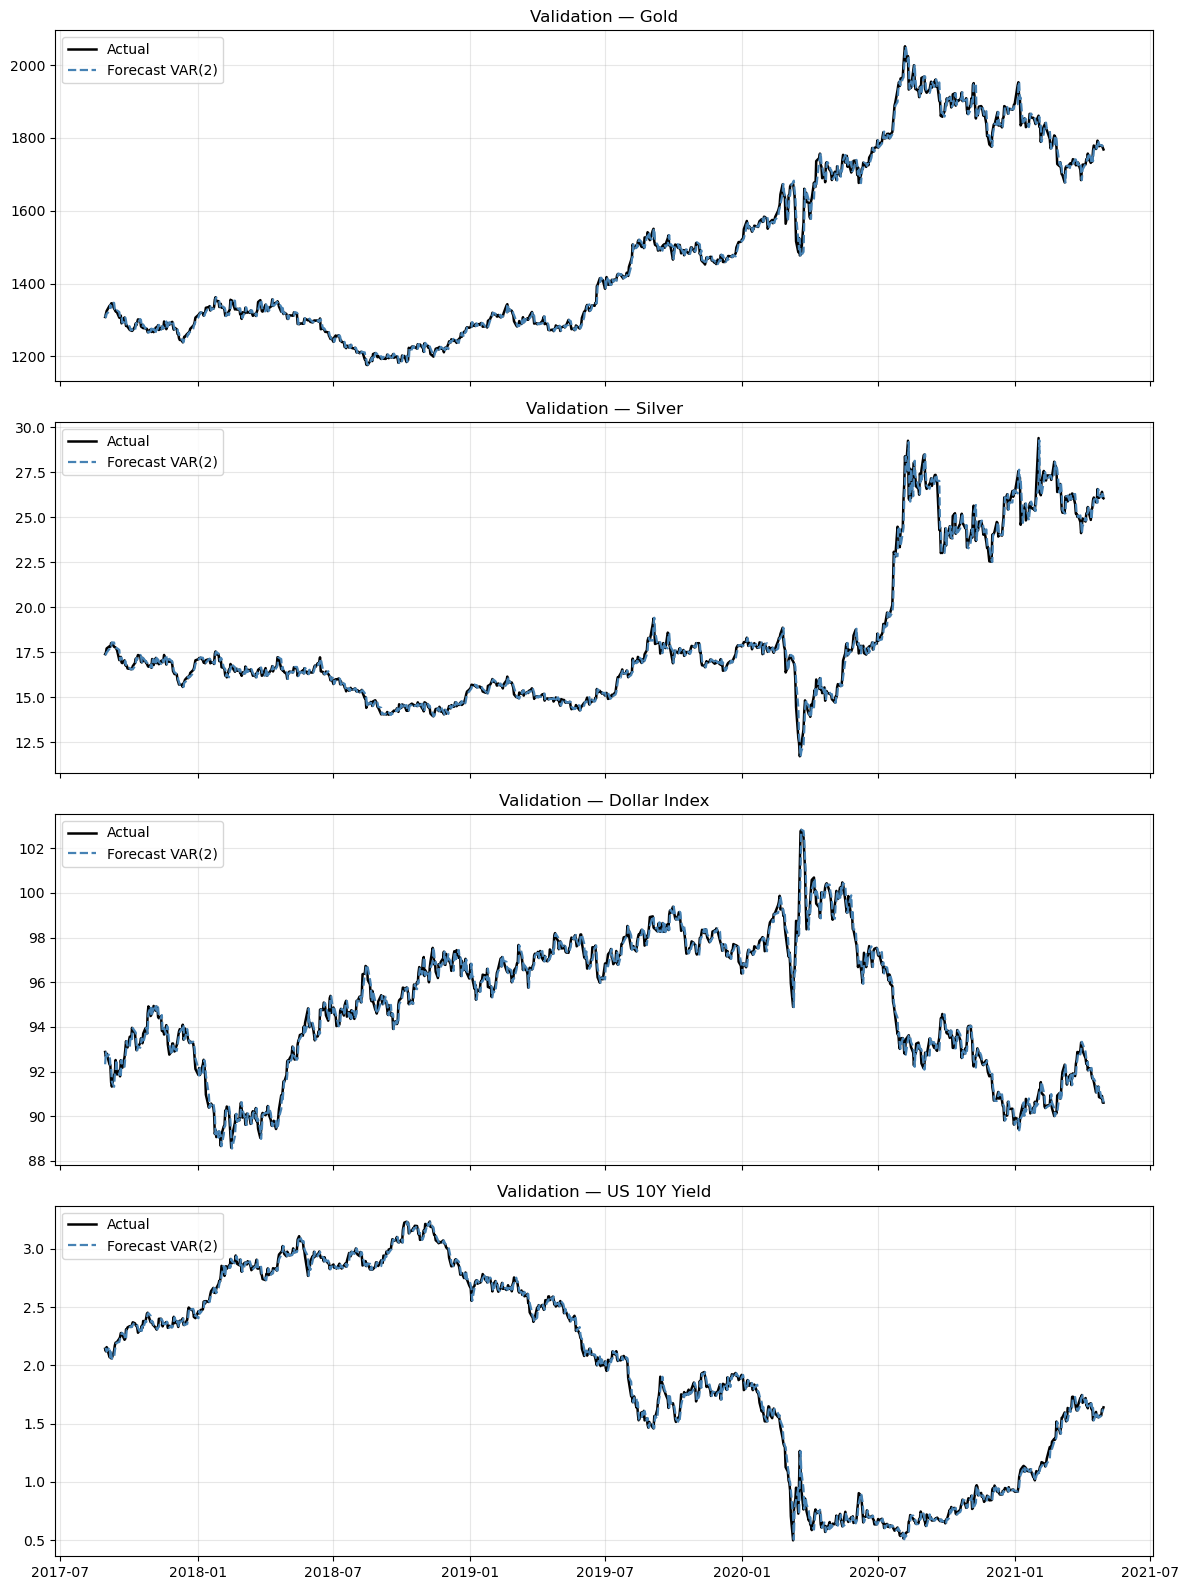

In [6]:
plot_forecast_levels(
    act_levels=act_levels_val_multi,
    pred_levels=pred_levels_val_multi,
    columns=log_cols_multi,
    model_label=f"VAR({final_lag_multi})",
    sample_label="Validation",
    variable_labels={
        "log_gold": "Gold",
        "log_silver": "Silver",
        "log_dxy": "Dollar Index",
        "us10y": "US 10Y Yield",
    },
)

Same pattern across all four series: the VAR(2) forecast tracks the 
realized path almost exactly, including the sharp us10y drop into the 
2020 easing cycle and its subsequent climb, and the volatile stretch in 
gold/silver around the same period. No visible drift or lag between the 
two lines anywhere in the sample.

This is the expected signature of a one-step-ahead forecast on series 
close to a random walk: the model is being re-anchored on yesterday's 
actual value at every step, so even a sharp move like the 2020 rate cut 
is "caught" immediately rather than missed, because the forecast horizon 
is one day, not several. It confirms stability of the walk-forward 
procedure across a 4-variable system, not genuine multi-day predictive 
power over rates or the dollar.

### 1.4 Evaluation on the test sample


In [7]:
test_start_multi = diff_data_full_multi.index.searchsorted(df_macro_test.index[0])
test_end_multi = diff_data_full_multi.index.searchsorted(df_macro_test.index[-1], side="right")

fc_test_multi = recursive_one_step_forecast_var(
    diff_data_full=diff_data_full_multi,
    log_data_full=log_data_full_multi,
    start_idx=test_start_multi,
    end_idx=test_end_multi,
    p=final_lag_multi,
)

pred_levels_test_multi = fc_test_multi["pred_levels"].copy()
act_levels_test_multi = fc_test_multi["act_levels"].copy()
pred_levels_test_multi[price_cols_multi] = np.exp(pred_levels_test_multi[price_cols_multi])
act_levels_test_multi[price_cols_multi] = np.exp(act_levels_test_multi[price_cols_multi])

test_metrics_multi = forecast_accuracy_table(pred_levels_test_multi, act_levels_test_multi)
test_metrics_multi["Lag"] = final_lag_multi
print("Test metrics — multivariate VAR(2)")
test_metrics_multi


c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier proje

Test metrics — multivariate VAR(2)


,RMSE,MAE,MAPE_%,Lag
Variable,,,,
log_gold,18.748286,13.858826,0.687117,2
log_silver,0.459228,0.334595,1.359002,2
log_dxy,0.468501,0.346022,0.336819,2
us10y,0.066731,0.052287,1.754066,2


MAPE rises slightly from validation across the board (gold 0.69% vs 
0.65%, silver 1.36% vs 1.25%, dxy 0.34% vs 0.28%), the expected pattern 
for a model that generalizes without overfitting.

us10y is the exception: test MAPE (1.75%) is lower than validation 
(2.30%), but that's a scale artifact, not better performance. Validation 
covered the 2020 collapse to near-zero yields, where tiny absolute 
errors inflate into large percentages; the test window doesn't have 
that stretch. RMSE/MAE (0.067 / 0.052, ~5-7bp average error) are the 
more stable read across samples.

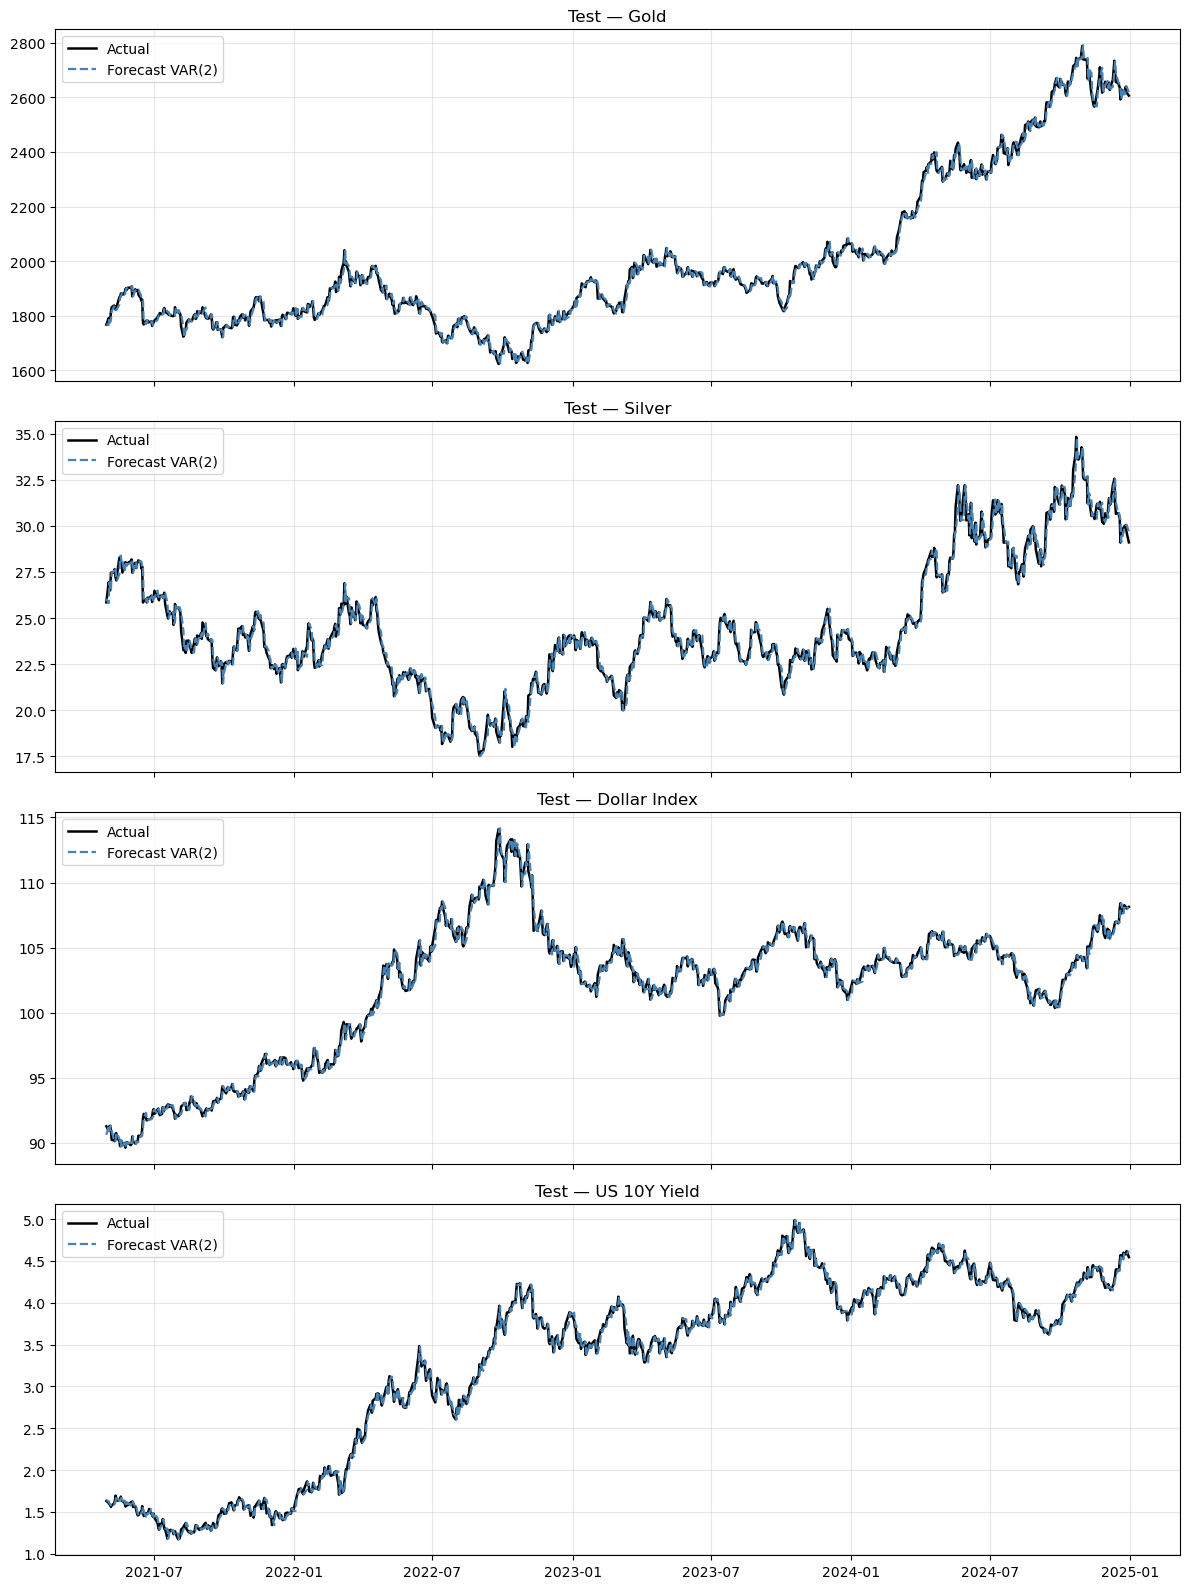

In [8]:
plot_forecast_levels(
    act_levels=act_levels_test_multi,
    pred_levels=pred_levels_test_multi,
    columns=log_cols_multi,
    model_label=f"VAR({final_lag_multi})",
    sample_label="Test",
    variable_labels={
        "log_gold": "Gold",
        "log_silver": "Silver",
        "log_dxy": "Dollar Index",
        "us10y": "US 10Y Yield",
    },
)

Compared to the bivariate VAR(1) (notebook 03: 0.677% gold, 1.360% silver),
gold/silver MAPE are essentially unchanged. Adding DXY and US10Y to the
system does not materially improve short-term forecastability of gold and
silver returns.

### 1.5 Re-estimation on the full sample


In [9]:
df_var_final_multi = clean_for_model(df_macro[diff_cols_multi])

final_var_multi_full = VAR(df_var_final_multi).fit(final_lag_multi)
print(final_var_multi_full.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 16, Sep, 2026
Time:                     09:13:48
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -34.4131
Nobs:                     6146.00    HQIC:                  -34.4388
Log likelihood:           71025.3    FPE:                1.09014e-15
AIC:                     -34.4525    Det(Omega_mle):     1.08378e-15
--------------------------------------------------------------------
Results for equation dlog_gold
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.000379         0.000138            2.748           0.006
L1.dlog_gold          -0.035691         0.021135           -1.689           0.091
L1.dlog_silver        -0.009171         0.011404    

c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Unlike the bivariate VAR (notebook 03, §1.6), where no lagged coefficient was
statistically significant, several cross-variable lagged effects are
significant here, validating the lag-2 choice from §1.1-1.2 rather than
just supporting it on information-criteria grounds alone.

- **Dollar channel confirmed**: L1.dlog_dxy is significant and negative for
  both dlog_gold (-0.146, p < 0.001) and dlog_silver (-0.279, p < 0.001),
  a DXY shock depresses gold/silver returns the next day, exactly as
  hypothesized in §0.
- **Opportunity-cost channel partially confirmed**: L1.dus10y is significant
  and negative for gold (-0.0085, p = 0.001) but not for silver (p = 0.909).
  Rate shocks weigh on gold specifically, less so on silver, consistent
  with gold's stronger role as a rate-sensitive store-of-value asset.
- **Contemporaneous dependence** (residual correlation) mirrors the pattern
  found for lagged effects: gold-silver correlation (0.781) is essentially
  identical to the bivariate case (§1.6, notebook 03: ≈0.78), while DXY is
  negatively correlated with both metals (-0.405 gold, -0.377 silver) and
  US10Y more weakly so (-0.172 gold, -0.056 silver), the same asymmetry as
  the lagged effects above.

Both macro-financial channels motivated in §0 show up in the estimated
system, at least for gold. This strengthens the structural case for the
four-variable extension, even though, as already noted in §1.3-1.4, it
does not translate into better short-term forecast accuracy.

### 1.6 Residual diagnostics


In [10]:
diagnostics_multi = var_diagnostics_table(df_var_final_multi, candidates=[1, final_lag_multi, 4], nlags_whiteness=12)
diagnostics_multi


c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,Whiteness p-value,Normalité p-value
Lag,,,,
1,-34.448013,-34.426137,1.150748e-14,0.0
2,-34.452469,-34.413086,3.338003e-10,0.0
4,-34.451495,-34.377084,5.252769e-09,0.0


AIC/BIC stay essentially flat across lags 1, 2 and 4. Whiteness and
normality are rejected (p < 0.05) at every lag, same pattern as the
bivariate VAR (notebook 03 §1.2/§1.7), the expected signature of daily
financial returns (volatility clustering, fat tails), not a misspecified
lag. VAR(2) is kept on the AIC/FPE + LR test grounds from §1.1-1.2, not on
residual diagnostics.

## 2. VECM on the macro-financial cointegration episode

### 2.1 Identification of the cointegration episode

Cointegration in the four-variable system is screened with a rolling
Engle-Granger-style test: `log_gold` is regressed by OLS on
`log_silver + log_dxy + us10y` over a rolling window of 1000 observations,
and the residual is tested for stationarity (ADF) at each window end. This
mirrors the bivariate rolling test in notebook 03, but is not a direct call
to `cointegration.rolling_engle_granger`,that function is bivariate-only
(it wraps `statsmodels.tsa.stattools.coint`, which takes exactly two series).
The multivariate case requires the OLS + ADF-on-residual construction
directly, as in the original study.


In [11]:
rolling_multi = rolling_cointegration(
    df_macro, target="log_gold", features=["log_silver", "log_dxy", "us10y"], window=1000
)
intervals_multi_df = find_significant_intervals(rolling_multi["p_value"], threshold=0.05)

In [12]:
best_interval_multi = intervals_multi_df.sort_values("Duration_days", ascending=False).iloc[0]
start_multi, end_multi = best_interval_multi["Start"], best_interval_multi["End"]

print(f"Selected cointegration episode: {start_multi.date()} → {end_multi.date()} "
      f"({best_interval_multi['N_observations']} observations)")

vecm_data_multi = df_macro.loc[start_multi:end_multi, log_cols_multi].dropna().copy()


Selected cointegration episode: 2013-01-22 → 2017-09-05 (1165 observations)


### 2.2 Local Johansen test : methodological note

Following the introduction of DXY and US10Y, cointegration episodes detected
by the rolling test are both more numerous and longer than in the bivariate
case (consistent with the motivation in §0: common macro-financial pricing
factors make a long-run relation more detectable). The longest episode is
used as the VECM estimation window, as in notebook 03.

**IMPORTANT : unlike the bivariate case**: in notebook 03, the local
Johansen trace test *confirmed* the rank-1 cointegration detected by the
rolling Engle-Granger test on the same window, the two independent methods
agreed. Here, the local Johansen trace test on this episode does **not**
reject H0 for r ≤ 0 at the 5% level: the trace statistic falls short of the
critical value, formally indicating rank 0 (no cointegration) on this window
by that test.

This is reported honestly rather than glossed over. The VECM below is still
estimated with `coint_rank = 1`, consistent with the rolling OLS+ADF
detection method that selected this episode in the first place, but this
choice rests on a single detection method rather than being cross-confirmed
by Johansen, which is a real methodological limitation of the multivariate
VECM relative to its bivariate counterpart. All downstream results (β, α,
ECT, IRF) should be read with that caveat in mind: they describe a
relationship one test detects and another does not corroborate on the exact
same window.


In [13]:
johansen_test_multi = coint_johansen(vecm_data_multi, det_order=0, k_ar_diff=1)

joh_local_multi_table = pd.DataFrame({
    "Hypothesis": [f"r <= {i}" for i in range(len(johansen_test_multi.lr1))],
    "Trace stat": johansen_test_multi.lr1,
    "Crit 5%": johansen_test_multi.cvt[:, 1],
    "Decision": [
        "Reject H0" if johansen_test_multi.lr1[i] > johansen_test_multi.cvt[i, 1] else "Non-reject H0"
        for i in range(len(johansen_test_multi.lr1))
    ],
})
joh_local_multi_table


,Hypothesis,Trace stat,Crit 5%,Decision
0,r <= 0,40.266391,47.8545,Non-reject H0
1,r <= 1,24.230550,29.7961,Non-reject H0
2,r <= 2,9.941727,15.4943,Non-reject H0
3,r <= 3,1.756124,3.8415,Non-reject H0


### 2.3 Stationarity on the sub-period


In [14]:
vecm_diff_multi = vecm_data_multi.diff().dropna()

level_table_vecm_multi = stationarity_table(vecm_data_multi)
diff_table_vecm_multi = stationarity_table(vecm_diff_multi)

print("Levels")
level_table_vecm_multi


Levels


,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Series,,,,,,
log_gold,-0.624000,0.444574,Non-stationary,1.853556,0.01,Non-stationary
log_silver,-1.301975,0.178238,Non-stationary,2.954769,0.01,Non-stationary
log_dxy,0.916237,0.903812,Non-stationary,4.669950,0.01,Non-stationary
us10y,-0.202013,0.613164,Non-stationary,1.302419,0.01,Non-stationary


In [15]:
print("First differences")
diff_table_vecm_multi


First differences


,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Series,,,,,,
log_gold,-18.700195,3.623298e-29,Stationary,0.312542,0.1,Stationary
log_silver,-12.797582,2.434532e-23,Stationary,0.305159,0.1,Stationary
log_dxy,-35.116151,0.000000e+00,Stationary,0.243934,0.1,Stationary
us10y,-35.085931,0.000000e+00,Stationary,0.101579,0.1,Stationary


### 2.4 Estimation of the multivariate VECM

`k_ar_diff = 1` is used, consistent with the lag selection in §1
(equivalent to a VAR(2) in levels, matching the multivariate VAR order
retained above, see notebook 03's discussion of the k_ar_diff / VAR-order
correspondence for the bivariate case).


In [16]:
print("VECM period:", start_multi.date(), "→", end_multi.date())
print("Number of observations:", len(vecm_data_multi))

vecm_res_multi = fit_vecm(vecm_data_multi, k_ar_diff=1, coint_rank=1, deterministic="co")
vecm_res_multi.summary()


VECM period: 2013-01-22 → 2017-09-05
Number of observations: 1165


c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0394,0.017,-2.387,0.017,-0.072,-0.007
L1.log_gold,-0.1027,0.055,-1.869,0.062,-0.210,0.005
L1.log_silver,0.0079,0.032,0.245,0.806,-0.055,0.071
L1.log_dxy,-0.1240,0.073,-1.693,0.090,-0.267,0.020
L1.us10y,-0.0168,0.007,-2.283,0.022,-0.031,-0.002
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0928,0.027,-3.441,0.001,-0.146,-0.040
L1.log_gold,-0.0723,0.090,-0.806,0.420,-0.248,0.103
L1.log_silver,-0.0622,0.052,-1.187,0.235,-0.165,0.040
L1.log_dxy,-0.1854,0.119,-1.552,0.121,-0.420,0.049


### 2.5 Long-run relation (beta) and adjustment coefficients (alpha)


In [17]:
beta_table_multi, alpha_table_multi = vecm_beta_alpha_tables(vecm_res_multi, log_cols_multi)
beta_table_multi


,Variable,Beta,Std_Error,t_stat,p_value
0,log_gold,1.000000,0.000000,0.000000,0.000000e+00
1,log_silver,-0.882133,0.128134,-6.884485,5.799805e-12
2,log_dxy,-0.375969,0.282054,-1.332971,1.825412e-01
3,us10y,0.061581,0.047527,1.295706,1.950766e-01


In [18]:
alpha_table_multi


,Equation,Alpha,Std_Error,t_stat,p_value
0,dlog_gold,0.012986,0.005467,2.375078,0.017545
1,dlog_silver,0.030533,0.008923,3.421865,0.000622
2,dlog_dxy,-0.001816,0.002384,-0.761865,0.446140
3,dus10y,-0.049368,0.023566,-2.094859,0.036184


log_silver's coefficient is the only one clearly significant (-0.882, p<0.001). Rearranged as log_gold = 0.882 log_silver + 0.376 log_dxy - 0.062 us10y, log_dxy actually comes out positive, the opposite sign from what the dollar-channel hypothesis in §0 predicted, and us10y comes out negative, which does match the opportunity-cost channel. Neither is significant though (p=0.183 and p=0.195), so I wouldn't read much into the signs: the long-run relation here is carried by gold and silver, dxy and us10y are just along for the ride.

Alpha tells a different story from the bivariate case. Gold's loading is now significant (0.013, p=0.018), not just silver's (0.031, p=0.0006), even if silver's is still more than twice as large. So gold isn't a pure price leader anymore once dxy and us10y are added to the system, it still adjusts less than silver but the adjustment is no longer negligible. dxy doesn't adjust at all (p=0.446), us10y does (-0.049, p=0.036).

### 2.6 Normalized relation and error correction term (ECT)


In [19]:
long_run_multi = normalized_long_run_relation(vecm_res_multi, log_cols_multi, normalize_on=0)

print("Estimated raw beta vector:")
print(long_run_multi["beta_raw"])

print("\nLong-run relation, normalized on log_gold:")
print(long_run_multi["equation_str"])


Estimated raw beta vector:
[ 1.         -0.88213321 -0.37596935  0.0615809 ]

Long-run relation, normalized on log_gold:
log_gold = -((-0.8821) * log_silver + (-0.3760) * log_dxy + (0.0616) * us10y)


In [20]:
vecm_data_multi["ECT"] = compute_ect(vecm_data_multi, long_run_multi["beta_normalized"], log_cols_multi)

vecm_data_multi[log_cols_multi + ["ECT"]].tail()


,log_gold,log_silver,log_dxy,us10y,ECT
Date,,,,,
2017-08-29,7.180146,2.857734,4.525586,2.136,3.089299
2017-08-30,7.176331,2.856700,4.531308,2.143,3.084676
2017-08-31,7.182504,2.861057,4.529045,2.121,3.086501
2017-09-01,7.188790,2.874638,4.530554,2.157,3.082458
2017-09-05,7.199828,2.881723,4.525152,2.070,3.083918


### 2.7 Summary table


In [21]:
summary_table_multi = vecm_summary_table(beta_table_multi, alpha_table_multi)
summary_table_multi


,Block,Name,Coefficient,Std_Error,t_stat,p_value
0,Long run (beta),log_gold,1.000000,0.000000,0.000000,0.000000e+00
1,Long run (beta),log_silver,-0.882133,0.128134,-6.884485,5.799805e-12
2,Long run (beta),log_dxy,-0.375969,0.282054,-1.332971,1.825412e-01
3,Long run (beta),us10y,0.061581,0.047527,1.295706,1.950766e-01
4,Adjustment (alpha),dlog_gold,0.012986,0.005467,2.375078,1.754524e-02
5,Adjustment (alpha),dlog_silver,0.030533,0.008923,3.421865,6.219308e-04
6,Adjustment (alpha),dlog_dxy,-0.001816,0.002384,-0.761865,4.461405e-01
7,Adjustment (alpha),dus10y,-0.049368,0.023566,-2.094859,3.618353e-02


### 2.8 Residual diagnostics : local VECM


In [22]:
diag_local_multi = vecm_residual_diagnostics(vecm_res_multi, log_cols_multi, lags=12)
diag_local_multi


,Series,LB stat,p-value,Decision
0,log_gold (residuals),16.819820,0.156502,Fail to reject H0
1,log_silver (residuals),20.306674,0.061503,Fail to reject H0
2,log_dxy (residuals),20.307919,0.061481,Fail to reject H0
3,us10y (residuals),13.037465,0.366323,Fail to reject H0


Residual diagnostics on this local window (§2.8) come back clean: none of the four Ljung-Box p-values reject H0 (0.157 gold, 0.062 silver, 0.061 dxy, 0.366 us10y). That's worth noting given §2.2's caveat: Johansen doesn't confirm rank 1 on this window, only the rolling OLS+ADF method detects the episode. Clean residuals don't resolve that disagreement between the two tests, but they are at least consistent with a correctly specified VECM on this window, which counts as some indirect support for keeping the episode despite the lack of formal cross-confirmation.

### 2.9 Re-estimation on the full sample

**Correction relative to the original study**: in the source notebook, the
cell labeled "re-estimation on the full sample" was fit on `vecm_data_multi`
- the same local 2013-2017 window used for the initial estimation in §2.4,
not on the full 2000-2024 dataset. Both cells produced identical output as a
result, which the original text did not catch. Here, the full sample
(`df_macro`) is used, so this is expected to differ from §2.4's results.


In [23]:
vecm_data_multi_full = clean_for_model(df_macro[log_cols_multi])

vecm_full_multi = fit_vecm(vecm_data_multi_full, k_ar_diff=1, coint_rank=1, deterministic="co")
print(vecm_full_multi.summary())


c:\dossier projet\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation log_gold
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0038      0.002      1.775      0.076      -0.000       0.008
L1.log_gold      -0.0359      0.021     -1.704      0.088      -0.077       0.005
L1.log_silver    -0.0089      0.011     -0.783      0.434      -0.031       0.013
L1.log_dxy       -0.1454      0.031     -4.635      0.000      -0.207      -0.084
L1.us10y         -0.0085      0.002     -3.455      0.001      -0.013      -0.004
Det. terms outside the coint. relation & lagged endog. parameters for equation log_silver
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0126      0.004      3.274      0.001       0.005       0.020
L1

In [24]:
diag_full_multi = vecm_residual_diagnostics(vecm_full_multi, log_cols_multi, lags=12)
diag_full_multi


,Series,LB stat,p-value,Decision
0,log_gold (residuals),30.169358,0.002633,Reject H0 (autocorrelation)
1,log_silver (residuals),19.331675,0.080832,Fail to reject H0
2,log_dxy (residuals),20.059158,0.065975,Fail to reject H0
3,us10y (residuals),19.307662,0.081369,Fail to reject H0


On the full sample, only gold's residuals show significant autocorrelation (p=0.0026). Silver, dxy and us10y are all borderline but technically don't reject H0 (p=0.081, 0.066, 0.081). This is a weaker signal than the bivariate case in notebook 03, where both series clearly failed the test. Still, three p-values sitting just above 0.05 isn't a picture of a well-specified full-sample model either. I'd read this as more evidence, even if less clean-cut, that imposing this one long-run relation outside its 2013-2017 window is a stretch, in line with the Johansen disagreement already flagged in §2.2.

## 3. Conclusion

VAR(2) is retained for the four-variable system after the LR test confirms it improves significantly on VAR(1) (LR=28.66, p=0.026), even though AIC/FPE and BIC/HQIC disagreed on the lag order beforehand. Residual diagnostics still show autocorrelation and non-normality regardless of lag, the same pattern as notebook 03, and I read it the same way: a linear VAR on daily returns isn't built to absorb volatility clustering, so this isn't treated as a specification issue to fix by adding lags. Out-of-sample MAPE stays low on the test set (0.69% gold, 1.36% silver, 0.34% dxy, 1.75% us10y), and the differences across variables mostly reflect their own scale of daily variation rather than any visible dollar or rate effect on forecast accuracy specifically.

The local VECM (2013-2017, 1165 obs) gives a long-run relation still dominated by gold and silver (beta_silver=-0.882, p<0.001), with dxy and us10y both carrying non-significant coefficients, and dxy's sign even running opposite to the dollar-channel hypothesis from §0. The price-leader/follower reading from the bivariate case doesn't survive unchanged either: gold's adjustment coefficient, non-significant in notebook 03, becomes significant here (p=0.018), even if still smaller than silver's. Extending the system to four variables weakens the clean bivariate story rather than confirming it.

The cointegration evidence for this episode is also weaker on its own terms than in the bivariate case. There, Johansen and rolling OLS+ADF agreed. Here, Johansen does not confirm rank 1 on the local window (§2.2), only the rolling method detects it. I don't think that disqualifies the episode, especially since the local VECM's residuals are clean (§2.9), but it's a real gap that should be stated rather than smoothed over.

The corrected full-sample re-estimation (§2.9-2.10) shows a milder version of what notebook 03 found for the bivariate case: gold's residuals are significantly autocorrelated, the other three variables are borderline. It's not as clean-cut, but it points the same way: imposing this relation outside 2013-2017 doesn't hold up well, which is consistent with treating this VECM, like the bivariate one, as a local exploratory tool rather than a structural result valid over the full sample.
